In [112]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [113]:
# Load the dataset
df = pd.read_csv('/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/Data/Model_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 210,528 rows × 20 columns
📅 Period covered: 2024-01-01 00:00:00 to 2025-12-31 23:55:00


In [114]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second
df['date'] = df['timestamp'].dt.date

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:00:00  2024      1    1     0       0       0
1 2024-01-01 00:05:00  2024      1    1     0       5       0
2 2024-01-01 00:10:00  2024      1    1     0      10       0
3 2024-01-01 00:15:00  2024      1    1     0      15       0
4 2024-01-01 00:20:00  2024      1    1     0      20       0
5 2024-01-01 00:25:00  2024      1    1     0      25       0
6 2024-01-01 00:30:00  2024      1    1     0      30       0
7 2024-01-01 00:35:00  2024      1    1     0      35       0
8 2024-01-01 00:40:00  2024      1    1     0      40       0
9 2024-01-01 00:45:00  2024      1    1     0      45       0


In [115]:
# =====================================================================
# 1.2 Drop non-predictive identifier and high correlated columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['date','packet_loss_rate_percent','rtt_ms','energy_efficiency_bits_per_joule','reliability_percent','throughput_ul_mbps','spectral_efficiency_bps_hz','bler_percent']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['date', 'packet_loss_rate_percent', 'rtt_ms', 'energy_efficiency_bits_per_joule', 'reliability_percent', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'bler_percent']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 210,528 rows x 19 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [116]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0

Distribution after encoding:
slice_type
0    210528
Name: count, dtype: int64


In [117]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 210,528 rows x 19 columns

Column types:
timestamp                        datetime64[ns]
slice_type                                int64
latitude                                float64
longitude                               float64
one_way_latency_ms                      float64
jitter_ms                               float64
packet_delay_budget_ms                  float64
handover_interruption_time_ms           float64
packet_loss_percent                     float64
throughput_dl_mbps                      float64
handover_success_rate_percent           float64
anomaly                                   int64
anomaly_type                             object
year                                      int32
month                                     int32
day                                       int32
hour                                      int32
minute                                    int32
second                                

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:00:00,0,33.800386,-7.547638,2.5865,0.5029,0.7614,5.2166,0.0005,106.5463,99.5036,0,normal,2024,1,1,0,0,0
1,2024-01-01 00:05:00,0,33.802700,-7.553952,2.4543,0.4950,0.7626,5.0939,0.0005,102.3002,99.4860,0,normal,2024,1,1,0,5,0
2,2024-01-01 00:10:00,0,33.800517,-7.556512,2.4245,0.4927,0.7753,5.1232,0.0005,97.0391,99.4985,0,normal,2024,1,1,0,10,0
3,2024-01-01 00:15:00,0,33.803398,-7.559040,2.4348,0.4907,0.7673,5.0829,0.0005,96.8969,99.5141,0,normal,2024,1,1,0,15,0
4,2024-01-01 00:20:00,0,33.809118,-7.551471,2.3904,0.4889,0.7729,5.0481,0.0005,101.7346,99.5181,0,normal,2024,1,1,0,20,0


In [118]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 210,528 rows x 19 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [119]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 16 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'packet_loss_percent', 'throughput_dl_mbps', 'handover_success_rate_percent', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(206127), 1: np.int64(4401)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(628), 1: np.int64(583), 2: np.int64(501), 3: np.int64(557), 4: np.int64(475), 5: np.int64(206127), 6: np.int64(519), 7: np.int64(509), 8: np.int64(629)}


In [120]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (210528, 16)  (16 features)
  y1 shape: (210528,)  (binary)
  y2 shape: (210528,)  (multi-class, 9 classes)

  X dtypes:
slice_type                         int64
latitude                         float64
longitude                        float64
one_way_latency_ms               float64
jitter_ms                        float64
packet_delay_budget_ms           float64
handover_interruption_time_ms    float64
packet_loss_percent              float64
throughput_dl_mbps               float64
handover_success_rate_percent    float64
year                               int32
month                              int32
day                                int32
hour                               int32
minute                             int32
second                             int32
dtype: object

  X preview:


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
0,0,33.800386,-7.547638,2.5865,0.5029,0.7614,5.2166,0.0005,106.5463,99.5036,2024,1,1,0,0,0
1,0,33.802700,-7.553952,2.4543,0.4950,0.7626,5.0939,0.0005,102.3002,99.4860,2024,1,1,0,5,0
2,0,33.800517,-7.556512,2.4245,0.4927,0.7753,5.1232,0.0005,97.0391,99.4985,2024,1,1,0,10,0
3,0,33.803398,-7.559040,2.4348,0.4907,0.7673,5.0829,0.0005,96.8969,99.5141,2024,1,1,0,15,0
4,0,33.809118,-7.551471,2.3904,0.4889,0.7729,5.0481,0.0005,101.7346,99.5181,2024,1,1,0,20,0


In [121]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y1_train distribution:
    Normal (0):  164,901 (97.91%)
    Anomaly (1): 3,521 (2.09%)

  y1_test distribution:
    Normal (0):  41,226 (97.91%)
    Anomaly (1): 880 (2.09%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (168422, 16)
  X_test:  (42106, 16)

  y2_train distribution:
    backhaul_issue (0): 502 (0.30%)
    handover_failure (1): 467 (0.28%)
    hardware_failure (2): 401 (0.24%)
    interference (3): 446 (0.26%)
    network_congestion (4): 380 (0.23%)
    normal (5): 164,901 (97.91%)
    overload (6): 415 (0.25%)
    security_attack (7): 407 (0.24%)
    signal_degradation (8): 503 (0.30%)

  y2_test distribution:
    backhaul_issue (0): 126 (0.30%)
    handover_failure (1): 116 (0.28%)
    hardware_failure (2): 100 (0.24%)
    interference (3): 111 (0.26%)
    network_congestion (4): 95 (0.23%)
    normal (5): 41,226 (97.91%)
    overload (6): 104 (0.25%)
    

## 4. Standardization (StandardScaler)

In [122]:
# =====================================================================
# 4.1 Apply StandardScaler
# =====================================================================
# Fit on training data ONLY, then transform both train and test sets
# This prevents data leakage from test set into training

scaler = StandardScaler()

# --- Binary classification sets ---
X_train_b_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_scaled = pd.DataFrame(
    scaler.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# --- Multi-class classification sets ---
scaler_m = StandardScaler()

X_train_m_scaled = pd.DataFrame(
    scaler_m.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_scaled = pd.DataFrame(
    scaler_m.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 4.2 Verification
# =====================================================================
print("="*70)
print("STANDARDIZATION - StandardScaler")
print("="*70)

print("--- Binary classification sets ---")
print(f"  X_train_b_scaled: {X_train_b_scaled.shape}")
print(f"  X_test_b_scaled:  {X_test_b_scaled.shape}")

print(" Train set statistics (mean ~ 0, std ~ 1):")
train_stats = pd.DataFrame({
    "Mean": X_train_b_scaled.mean().round(6),
    "Std": X_train_b_scaled.std().round(6)
})
print(train_stats)

print("Test set statistics:")
test_stats = pd.DataFrame({
    "Mean": X_test_b_scaled.mean().round(6),
    "Std": X_test_b_scaled.std().round(6)
})
print(test_stats)

print("--- Multi-class classification sets ---")
print(f"  X_train_m_scaled: {X_train_m_scaled.shape}")
print(f"  X_test_m_scaled:  {X_test_m_scaled.shape}")

print("Preview (X_train_b_scaled):")
X_train_b_scaled.head()

STANDARDIZATION - StandardScaler
--- Binary classification sets ---
  X_train_b_scaled: (168422, 16)
  X_test_b_scaled:  (42106, 16)
 Train set statistics (mean ~ 0, std ~ 1):
                               Mean       Std
slice_type                      0.0  0.000000
latitude                       -0.0  1.000003
longitude                       0.0  1.000003
one_way_latency_ms              0.0  1.000003
jitter_ms                      -0.0  1.000003
packet_delay_budget_ms          0.0  1.000003
handover_interruption_time_ms  -0.0  1.000003
packet_loss_percent            -0.0  1.000003
throughput_dl_mbps             -0.0  1.000003
handover_success_rate_percent  -0.0  1.000003
year                           -0.0  1.000003
month                          -0.0  1.000003
day                            -0.0  1.000003
hour                            0.0  1.000003
minute                          0.0  1.000003
second                          0.0  0.000000
Test set statistics:
                     

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
38000,0.0,-2.311899,0.470150,-0.068084,-0.080454,-0.120537,-0.014758,-0.082691,0.069209,0.104043,-0.999157,-0.442551,-0.537601,1.517779,0.724767,0.0
66803,0.0,-0.337148,1.019846,-0.064099,-0.079627,-0.062109,-0.038860,-0.082691,0.018927,0.070918,-0.999157,0.427758,0.372097,1.517779,1.593922,0.0
5081,0.0,-0.951292,1.074995,-0.061371,-0.021519,-0.229096,-0.008077,-0.082691,-0.113561,0.093306,-0.999157,-1.602963,0.258385,0.506064,-0.144388,0.0
107831,0.0,-1.176092,0.486335,-0.089664,-0.086244,-0.089520,0.009514,-0.082691,0.561127,0.086323,1.000843,-1.602963,-0.765026,-0.361121,1.593922,0.0
129005,0.0,0.462361,0.676761,-0.080030,-0.060499,-0.016305,-0.036819,-0.082691,0.463725,0.072041,1.000843,-1.022757,0.826946,1.517779,-0.144388,0.0


## 5. Distribution des Features apres Standardisation

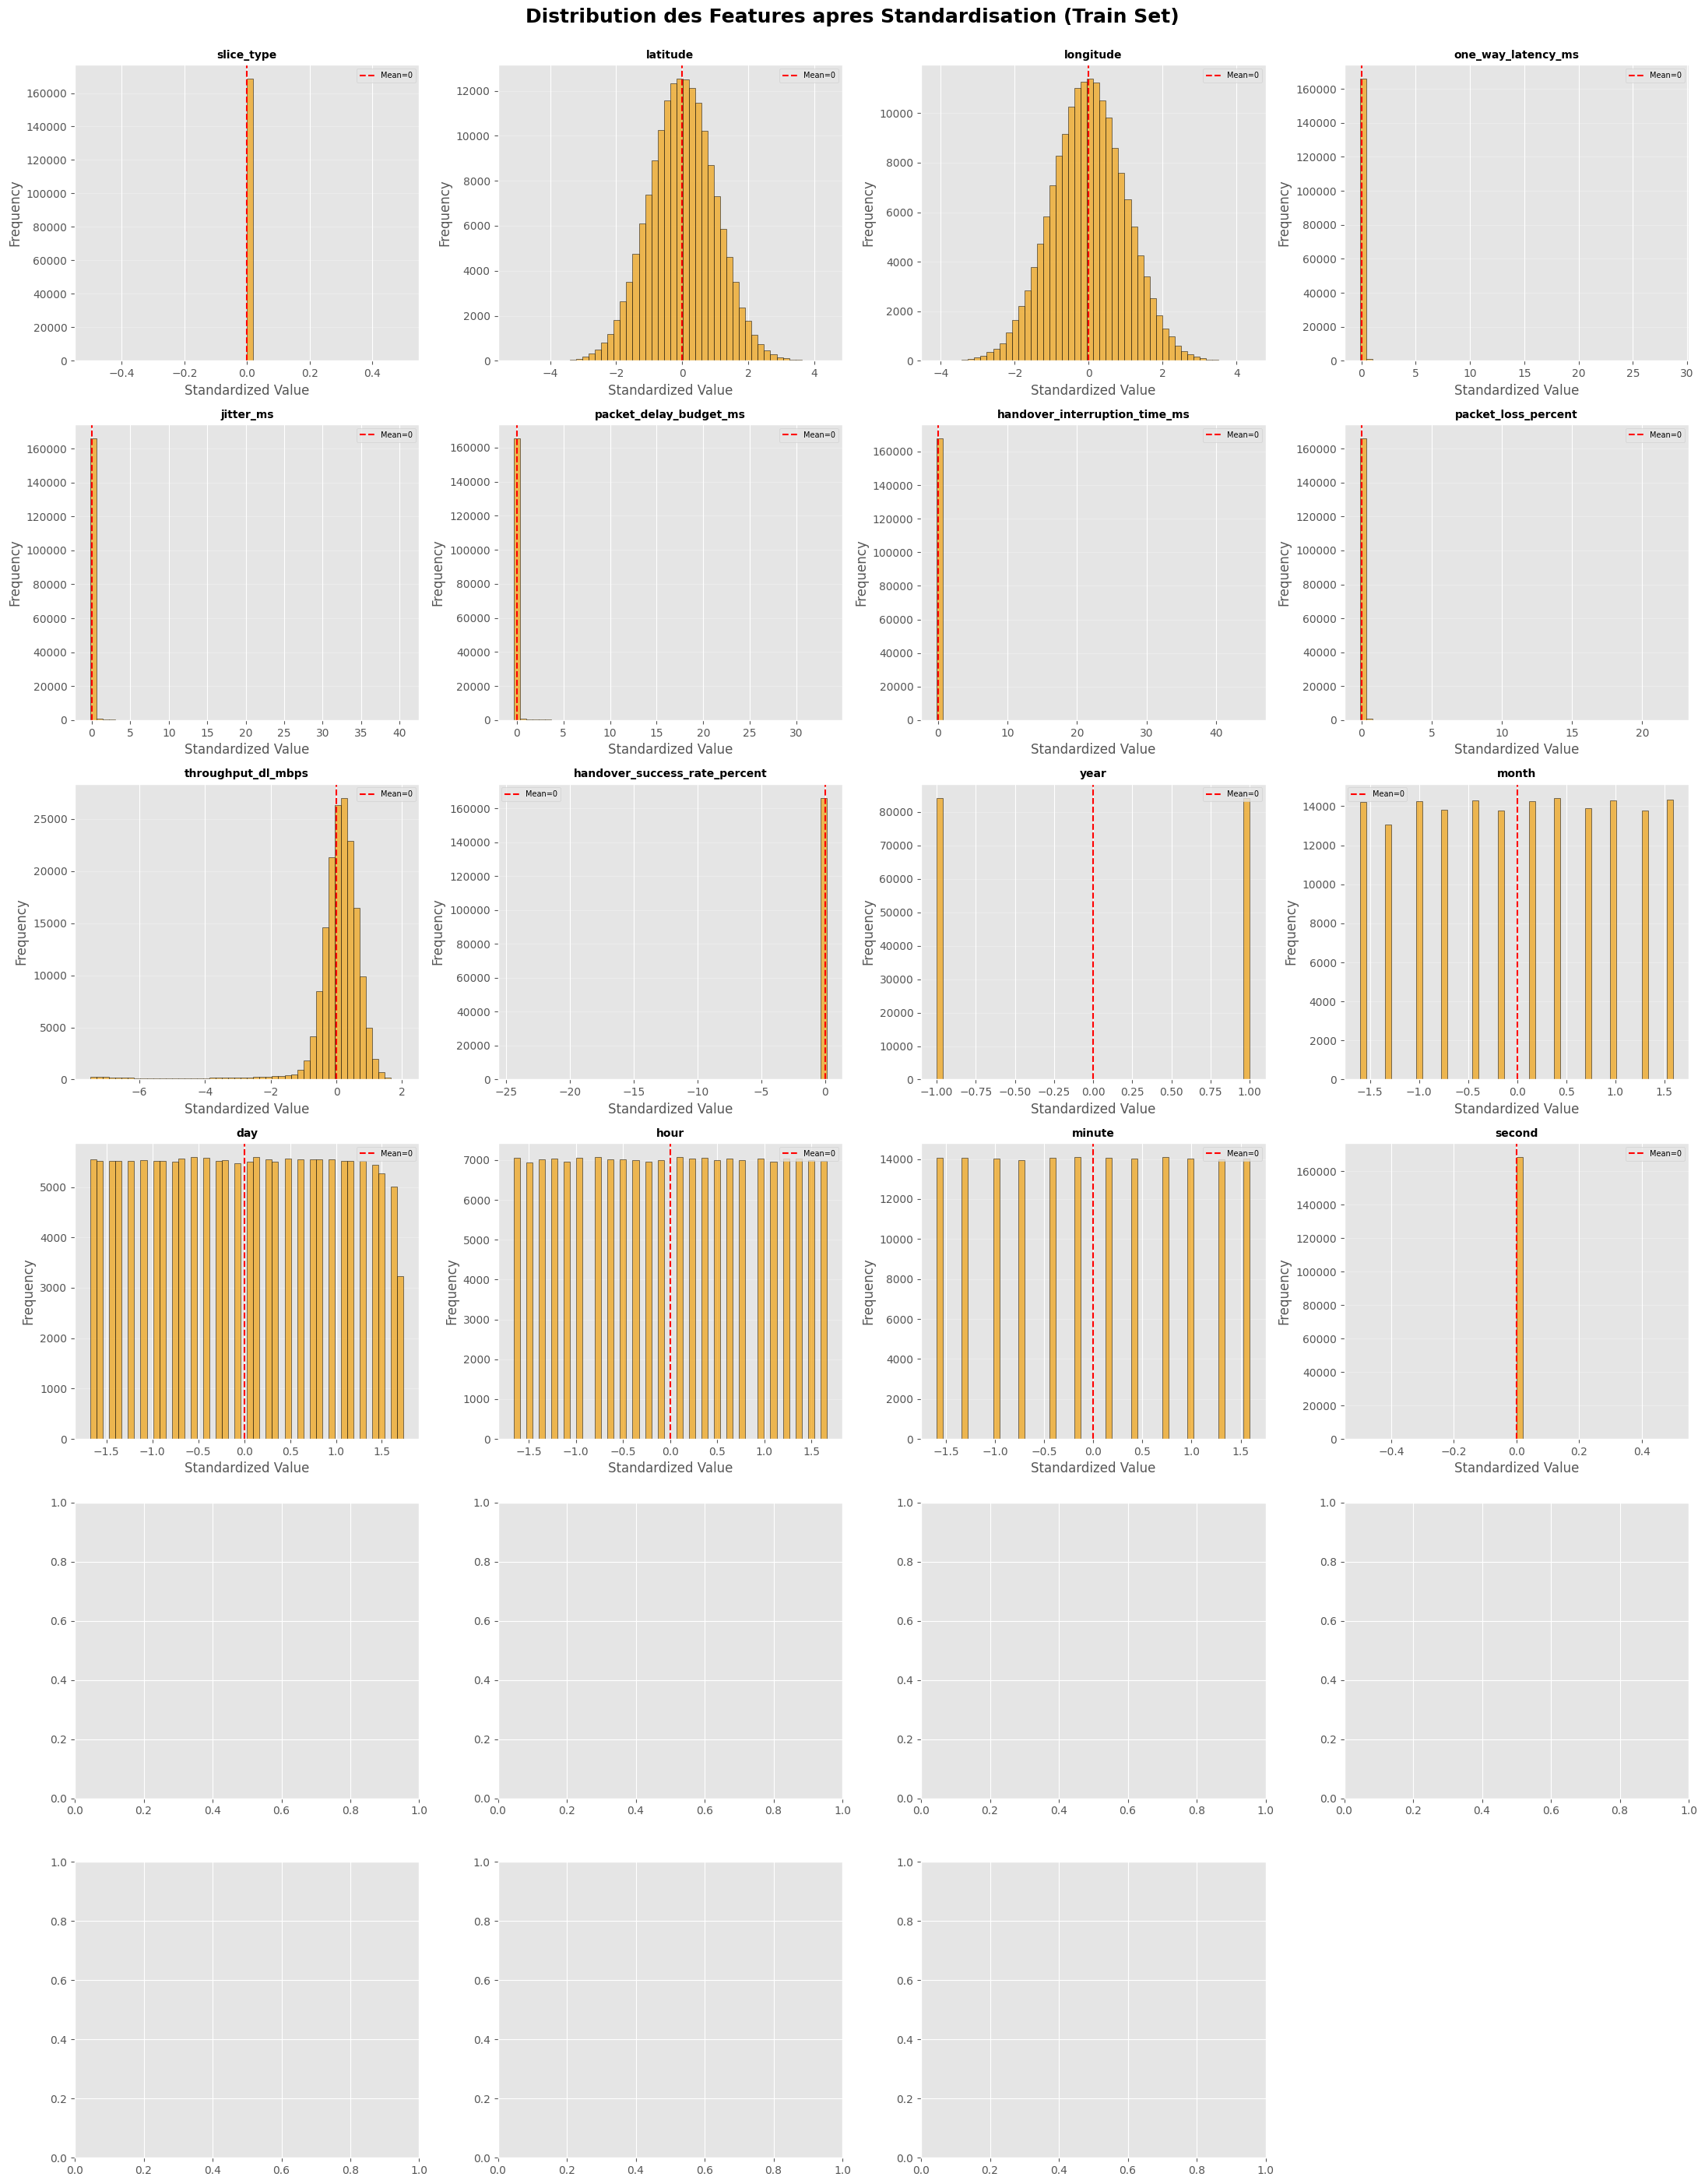

All 16 features are standardized (mean ~ 0, std ~ 1)


In [123]:
# =====================================================================
# 5. Distribution des Features apres Standardisation
# =====================================================================

fig, axes = plt.subplots(6, 4, figsize=(22, 28))
axes = axes.ravel()

for idx, col in enumerate(X_train_b_scaled.columns):
    axes[idx].hist(X_train_b_scaled[col], bins=50, color="#f0a10f",
                   alpha=0.7, edgecolor='black')
    axes[idx].set_title(col, fontsize=10, fontweight='bold')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean=0')
    axes[idx].set_xlabel('Standardized Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplot (24 subplots, 23 features)
axes[-1].set_visible(False)

plt.suptitle('Distribution des Features apres Standardisation (Train Set)',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"All {X_train_b_scaled.shape[1]} features are standardized (mean ~ 0, std ~ 1)")

## 5.bis Comparaison des Transformations : Yeo-Johnson vs Quantile Transformer

StandardScaler ne change pas la forme de la distribution (seulement mean=0, std=1).
Pour rapprocher les distributions d'une loi normale, on compare deux approches :
- **Yeo-Johnson (PowerTransformer)** : trouve automatiquement le lambda optimal par feature
- **QuantileTransformer (Gaussian)** : force une distribution normale parfaite

In [124]:
# =====================================================================
# 5.bis.1 Apply Yeo-Johnson and Quantile Transformers
# =====================================================================
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# --- Yeo-Johnson PowerTransformer ---
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_b_yeojohnson = pd.DataFrame(
    pt_yj.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

# --- Quantile Transformer (Gaussian output) ---
qt_gauss = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
X_train_b_quantile = pd.DataFrame(
    qt_gauss.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)

print("="*70)
print("TRANSFORMATIONS APPLIED")
print("="*70)
print(f"\n1. Yeo-Johnson (PowerTransformer):")
print(f"   Shape: {X_train_b_yeojohnson.shape}")
print(f"   Mean range: [{X_train_b_yeojohnson.mean().min():.6f}, {X_train_b_yeojohnson.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_yeojohnson.std().min():.4f}, {X_train_b_yeojohnson.std().max():.4f}]")

print(f"\n2. Quantile Transformer (Gaussian):")
print(f"   Shape: {X_train_b_quantile.shape}")
print(f"   Mean range: [{X_train_b_quantile.mean().min():.6f}, {X_train_b_quantile.mean().max():.6f}]")
print(f"   Std range:  [{X_train_b_quantile.std().min():.4f}, {X_train_b_quantile.std().max():.4f}]")

TRANSFORMATIONS APPLIED

1. Yeo-Johnson (PowerTransformer):
   Shape: (168422, 16)
   Mean range: [-0.000000, 0.000000]
   Std range:  [0.0000, 1.0000]

2. Quantile Transformer (Gaussian):
   Shape: (168422, 16)
   Mean range: [-5.199338, 0.011799]
   Std range:  [0.0000, 5.1994]


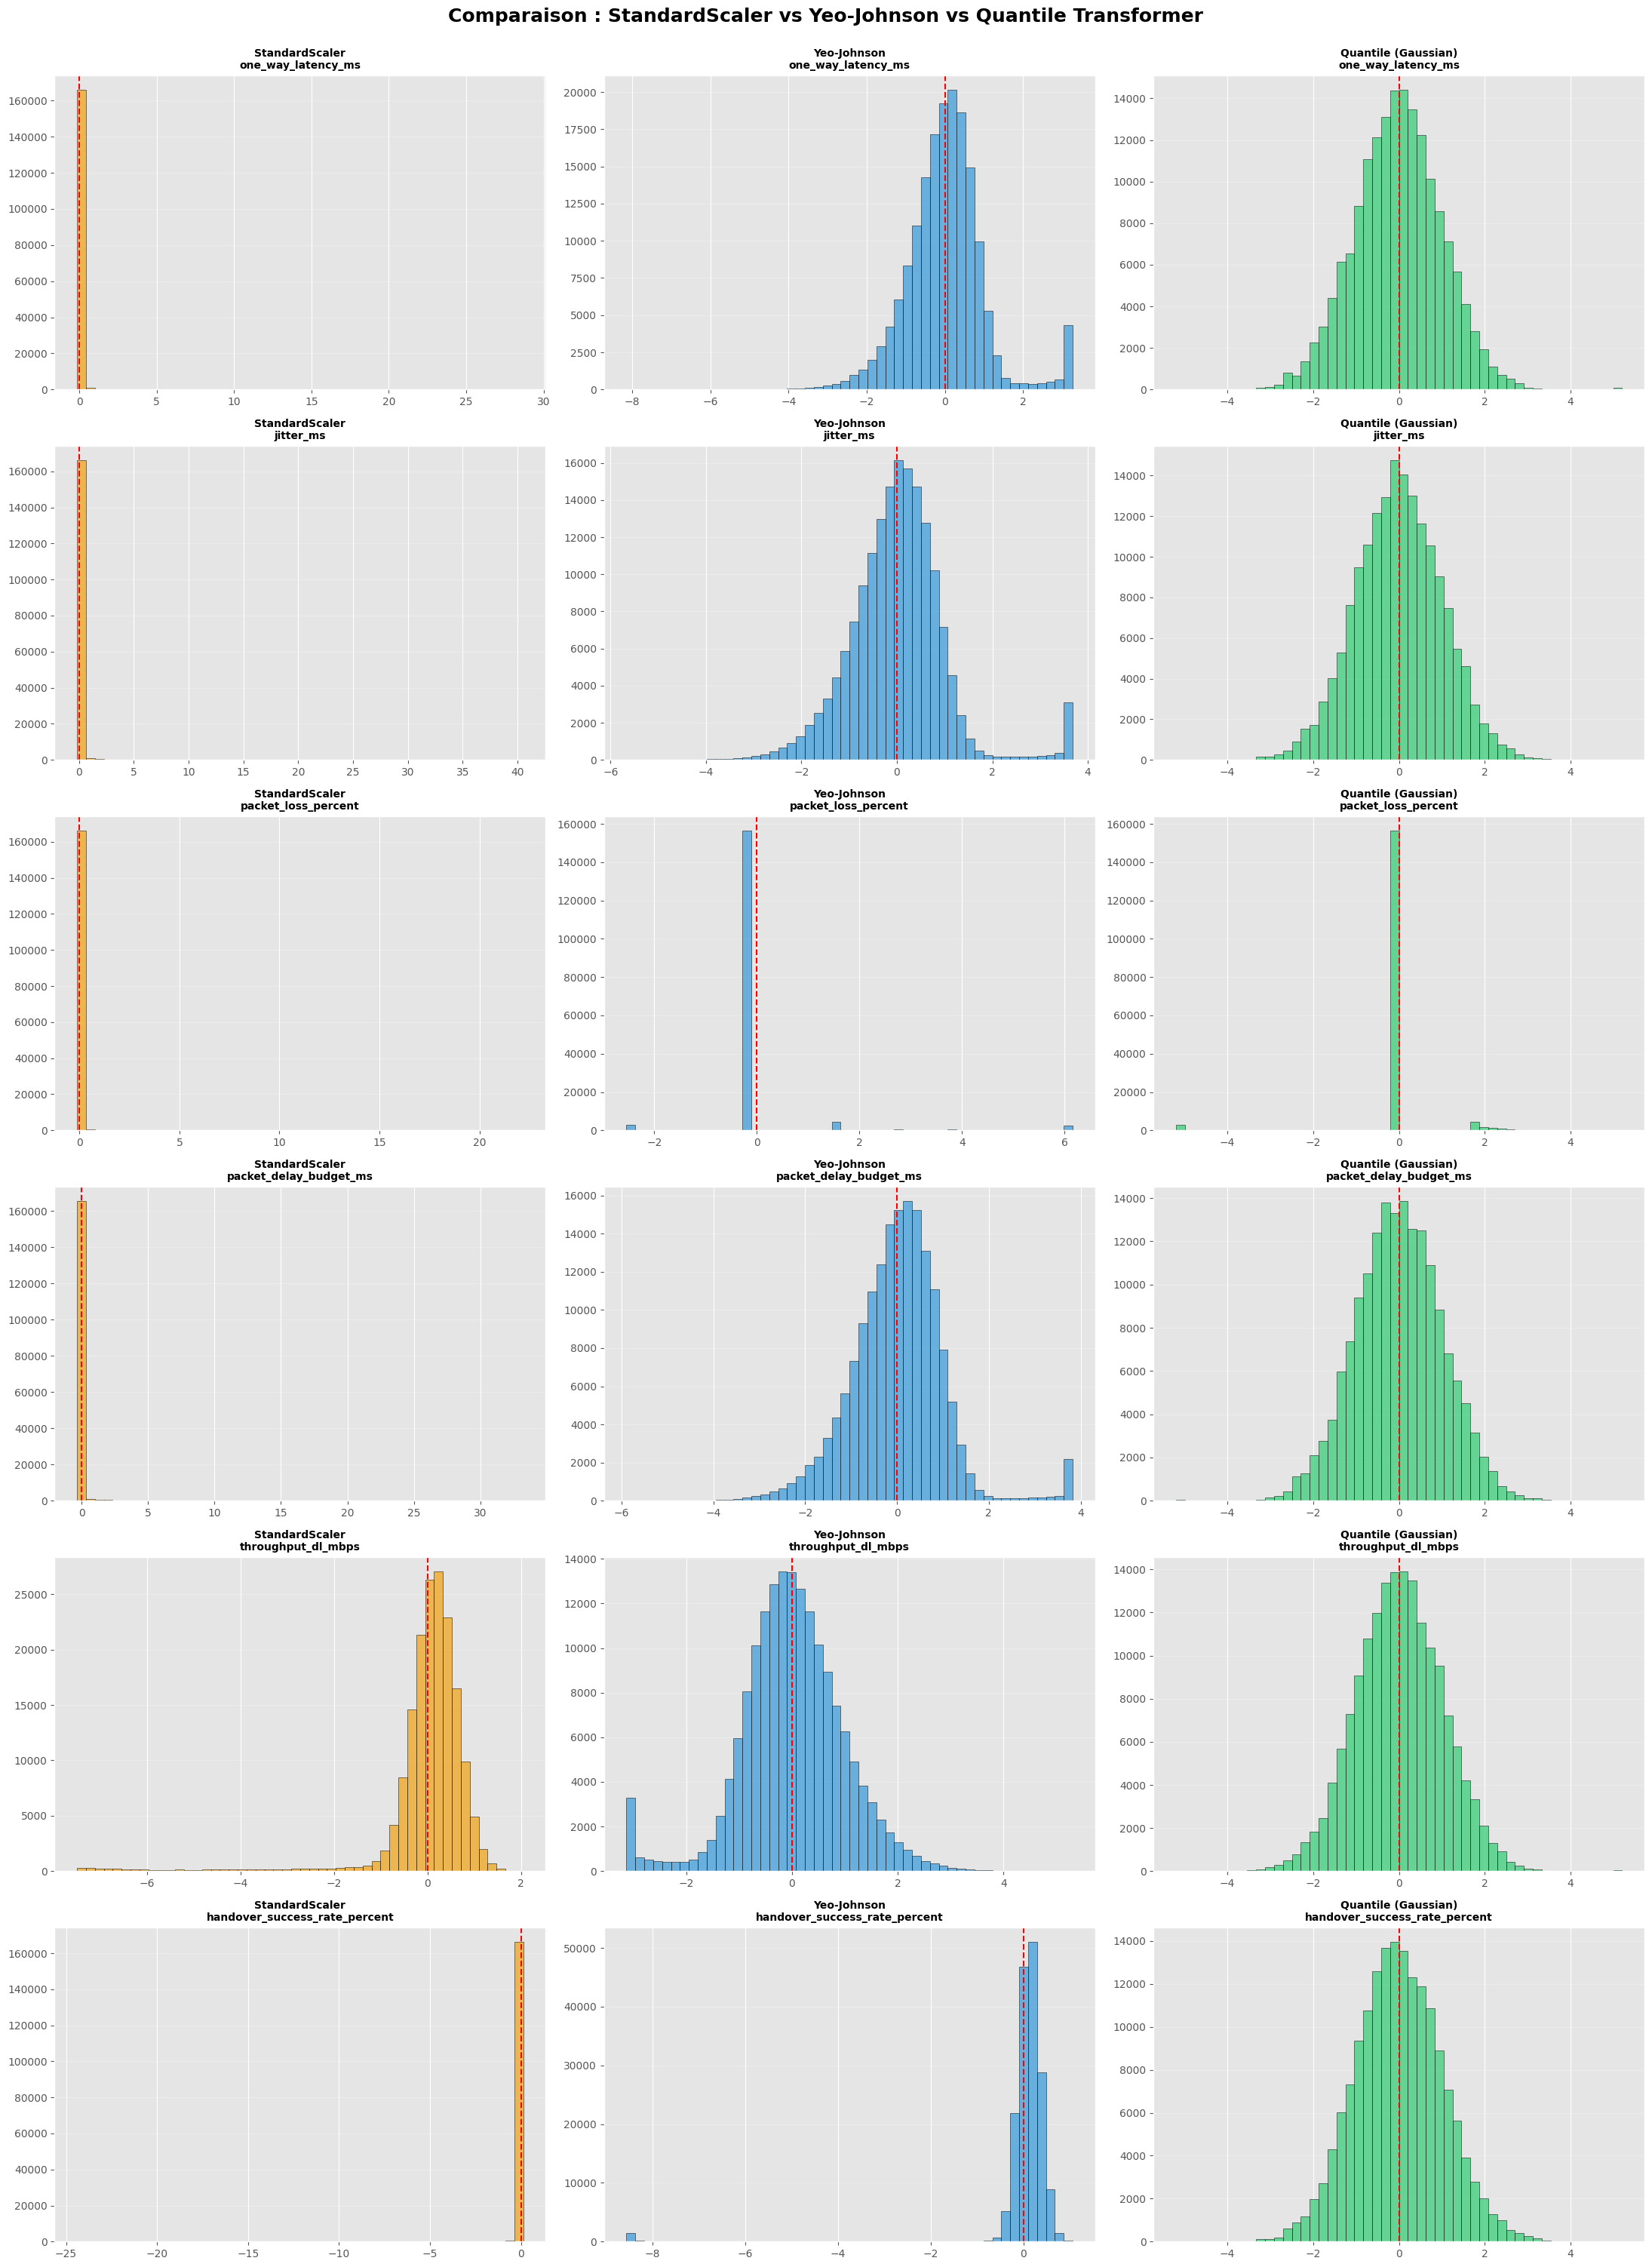

SHAPIRO-WILK COMPARISON (sample=5000)

Feature                                   StandardScaler     Yeo-Johnson        Quantile
---------------------------------------------------------------------------------------
slice_type                                      1.0000 *        1.0000 *        1.0000 *
latitude                                        0.9997        0.9997        0.9998 *
longitude                                       0.9997 *        0.9997        0.9992
one_way_latency_ms                              0.0629        0.9395        0.9989 *
jitter_ms                                       0.0699        0.9345        0.9996 *
packet_delay_budget_ms                          0.0818        0.9483        0.9992 *
handover_interruption_time_ms                   0.0348        0.9618        0.9994 *
packet_loss_percent                             0.0648        0.2966        0.3132 *
throughput_dl_mbps                              0.5965        0.9711        0.9990 *
handover_succes

In [125]:
# =====================================================================
# 5.bis.2 Visual Comparison: StandardScaler vs Yeo-Johnson vs Quantile
# =====================================================================
# Select 6 representative features available in the current dataset
features_to_compare = [
    'one_way_latency_ms', 'jitter_ms', 'packet_loss_percent',
    'packet_delay_budget_ms', 'throughput_dl_mbps', 'handover_success_rate_percent'
]

fig, axes = plt.subplots(len(features_to_compare), 3, figsize=(22, 5 * len(features_to_compare)))

for row, feat in enumerate(features_to_compare):
    # Column 1: StandardScaler
    axes[row, 0].hist(X_train_b_scaled[feat], bins=50, color="#f0a10f", alpha=0.7, edgecolor='black')
    axes[row, 0].set_title(f'StandardScaler\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 0].grid(axis='y', alpha=0.3)

    # Column 2: Yeo-Johnson
    axes[row, 1].hist(X_train_b_yeojohnson[feat], bins=50, color="#3498db", alpha=0.7, edgecolor='black')
    axes[row, 1].set_title(f'Yeo-Johnson\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].grid(axis='y', alpha=0.3)

    # Column 3: Quantile Transformer
    axes[row, 2].hist(X_train_b_quantile[feat], bins=50, color="#2ecc71", alpha=0.7, edgecolor='black')
    axes[row, 2].set_title(f'Quantile (Gaussian)\n{feat}', fontsize=10, fontweight='bold')
    axes[row, 2].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison : StandardScaler vs Yeo-Johnson vs Quantile Transformer',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# =====================================================================
# Shapiro-Wilk comparison on a sample
# =====================================================================
from scipy import stats

print("="*80)
print("SHAPIRO-WILK COMPARISON (sample=5000)")
print("="*80)
print(f"\n{'Feature':<40} {'StandardScaler':>15} {'Yeo-Johnson':>15} {'Quantile':>15}")
print("-" * 87)

sample_size = 5000
for feat in X_train_b_scaled.columns:
    w_std, _ = stats.shapiro(X_train_b_scaled[feat].sample(sample_size, random_state=42))
    w_yj, _ = stats.shapiro(X_train_b_yeojohnson[feat].sample(sample_size, random_state=42))
    w_qt, _ = stats.shapiro(X_train_b_quantile[feat].sample(sample_size, random_state=42))
    
    # Mark the best W statistic (closest to 1)
    best = max(w_std, w_yj, w_qt)
    mark_std = " *" if w_std == best else ""
    mark_yj = " *" if w_yj == best else ""
    mark_qt = " *" if w_qt == best else ""
    
    print(f"{feat:<40} {w_std:>13.4f}{mark_std} {w_yj:>13.4f}{mark_yj} {w_qt:>13.4f}{mark_qt}")

print("\n* = best W statistic (closest to 1 = most normal)")
print("\nConclusion:")
print("   Yeo-Johnson: recommended for most ML models (natural normalization)")
print("   Quantile: forces perfect Gaussian but may distort feature relationships")

# =====================================================================
# MODELISATION with STANDARDSCALER
# =====================================================================
Pour SVM, nous utilisons **StandardScaler** pour normaliser les features avant l'entraînement des modèles.
Cette approche est bien adaptée aux SVM car elle met toutes les variables sur une echelle comparable.

## Step 6: QuantileTransformer — Préparation des jeux de données

In [126]:
# =====================================================================
# 6.1 Apply QuantileTransformer to Binary Classification Sets
# =====================================================================
from sklearn.preprocessing import QuantileTransformer

# Fit on training data ONLY, then transform both train and test
qt_binary = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_b_qt = pd.DataFrame(
    qt_binary.fit_transform(X_train_b),
    columns=X_train_b.columns,
    index=X_train_b.index
)
X_test_b_qt = pd.DataFrame(
    qt_binary.transform(X_test_b),
    columns=X_test_b.columns,
    index=X_test_b.index
)

# =====================================================================
# 6.2 Apply QuantileTransformer to Multi-class Classification Sets
# =====================================================================
qt_multi = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)

X_train_m_qt = pd.DataFrame(
    qt_multi.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)
X_test_m_qt = pd.DataFrame(
    qt_multi.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

# =====================================================================
# 6.3 Verification
# =====================================================================
print("="*70)
print("QUANTILE TRANSFORMER - DATASETS READY")
print("="*70)

print("\n--- Binary Classification ---")
print(f"  X_train_b_qt: {X_train_b_qt.shape}")
print(f"  X_test_b_qt:  {X_test_b_qt.shape}")
print(f"  Train mean range: [{X_train_b_qt.mean().min():.4f}, {X_train_b_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_b_qt.std().min():.4f}, {X_train_b_qt.std().max():.4f}]")

print("\n--- Multi-class Classification ---")
print(f"  X_train_m_qt: {X_train_m_qt.shape}")
print(f"  X_test_m_qt:  {X_test_m_qt.shape}")
print(f"  Train mean range: [{X_train_m_qt.mean().min():.4f}, {X_train_m_qt.mean().max():.4f}]")
print(f"  Train std range:  [{X_train_m_qt.std().min():.4f}, {X_train_m_qt.std().max():.4f}]")

print("\nPreview (X_train_b_qt):")
X_train_b_qt.head()

QUANTILE TRANSFORMER - DATASETS READY

--- Binary Classification ---
  X_train_b_qt: (168422, 16)
  X_test_b_qt:  (42106, 16)
  Train mean range: [-5.1993, 0.0118]
  Train std range:  [0.0000, 5.1994]

--- Multi-class Classification ---
  X_train_m_qt: (168422, 16)
  X_test_m_qt:  (42106, 16)
  Train mean range: [-5.1993, 0.0126]
  Train std range:  [0.0000, 5.1994]

Preview (X_train_b_qt):


,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,packet_delay_budget_ms,handover_interruption_time_ms,packet_loss_percent,throughput_dl_mbps,handover_success_rate_percent,year,month,day,hour,minute,second
38000,-5.199338,-2.316873,0.479119,0.522099,-0.170185,-0.702315,0.955251,-0.047692,-0.149373,1.887753,-5.199338,-0.340163,-0.384375,1.550085,0.552537,-5.199338
66803,-5.199338,-0.344060,1.025761,0.790155,-0.142244,0.217488,0.110021,-0.047692,-0.251869,-0.849655,-5.199338,0.292676,0.292676,1.550085,5.199338,-5.199338
5081,-5.199338,-0.964181,1.083431,0.958305,1.649002,-2.417279,1.177852,-0.047692,-0.525522,0.959440,-5.199338,-5.199338,0.207223,0.385726,-0.111890,-5.199338
107831,-5.199338,-1.200444,0.496234,-0.976979,-0.392492,-0.217488,1.756704,-0.047692,0.937461,0.385726,5.199338,-5.199338,-0.570161,-0.271787,5.199338,-5.199338
129005,-5.199338,0.456412,0.689679,-0.276856,0.573115,0.912774,0.185115,-0.047692,0.716406,-0.772563,5.199338,-0.830234,0.650274,1.550085,-0.111890,-5.199338


# =====================================================================
# MODÈLE BASELINE — SVM (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **SVM (Support Vector Machine)** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Les données utilisées pour SVM sont transformées par **StandardScaler**.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

SVM BASELINE — CLASSIFICATION BINAIRE (StandardScaler)

Paramètres par défaut:
   C:       1.0
   kernel:  rbf
   gamma:   scale
   degree:  3

✅ Entraînement terminé en 241.65s

RÉSULTATS BASELINE — Classification Binaire (StandardScaler)

  Accuracy:  0.9952
  Precision: 0.9694
  Recall:    0.7932
  F1-Score:  0.8725
  ROC-AUC:   0.9143

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     41226
     Anomaly       0.97      0.79      0.87       880

    accuracy                           1.00     42106
   macro avg       0.98      0.90      0.94     42106
weighted avg       1.00      1.00      0.99     42106



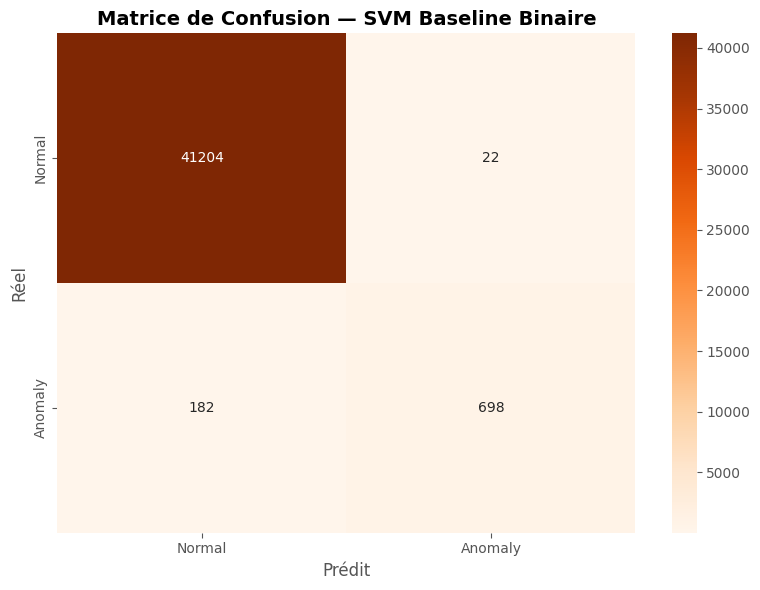

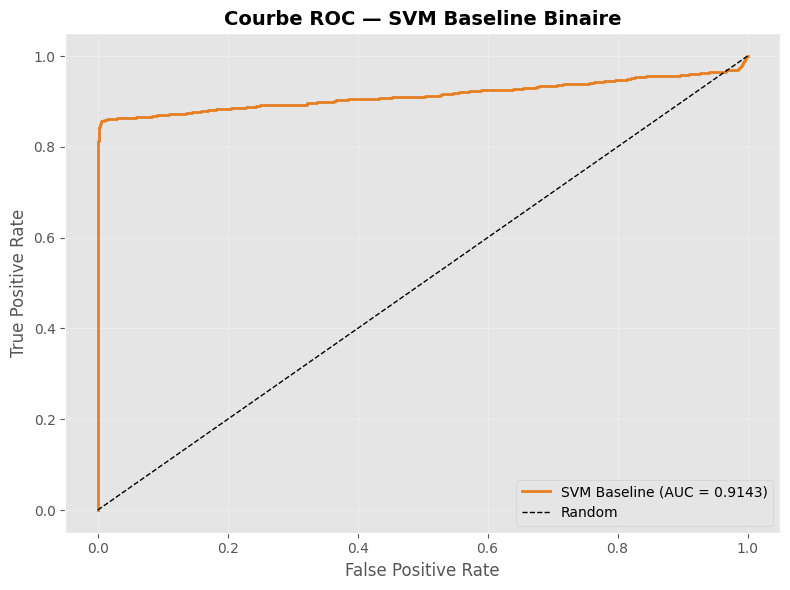

In [127]:
# =====================================================================
# 7.0.1 SVM Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("SVM BASELINE — CLASSIFICATION BINAIRE (StandardScaler)")
print("="*70)

svm_baseline_b = SVC(probability=True, random_state=42)

print(f"\nParamètres par défaut:")
print(f"   C:       {svm_baseline_b.C}")
print(f"   kernel:  {svm_baseline_b.kernel}")
print(f"   gamma:   {svm_baseline_b.gamma}")
print(f"   degree:  {svm_baseline_b.degree}")

# --- Entraînement ---
start_time = time.time()
svm_baseline_b.fit(X_train_b_scaled, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = svm_baseline_b.predict(X_test_b_scaled)
y1_proba_baseline = svm_baseline_b.predict_proba(X_test_b_scaled)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — SVM Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'SVM Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — SVM Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

SVM BASELINE — CLASSIFICATION MULTI-CLASSES (StandardScaler)

⚡ Train multi échantillonné: 39,995 / 168,422 lignes

Paramètres utilisés:
   C:            1.0
   kernel:       rbf
   gamma:        scale
   class_weight: balanced
   max_iter:     3000

✅ Entraînement terminé en 19.57s

RÉSULTATS BASELINE — Classification Multi-classes (StandardScaler)

  Accuracy:             0.0834
  Precision (weighted): 0.9768
  Recall (weighted):    0.0834
  F1-Score (weighted):  0.1261

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.03      0.88      0.06       126
  handover_failure       0.01      0.90      0.02       116
  hardware_failure       0.02      0.70      0.03       100
      interference       0.02      0.81      0.03       111
network_congestion       0.02      0.80      0.04        95
            normal       1.00      0.07      0.13     41226
          overload       0.03      0.68      0.06       104
   security_atta

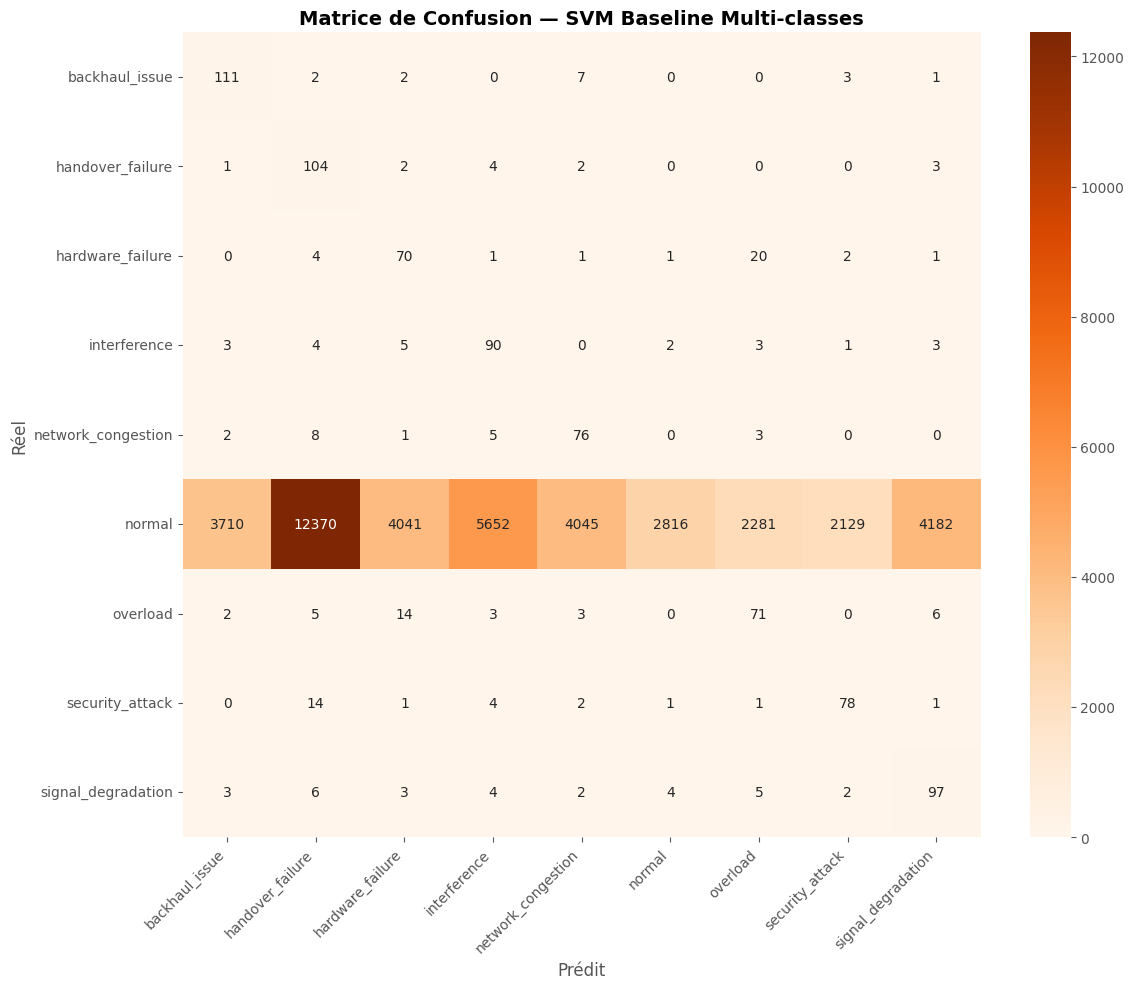


📋 RÉSUMÉ BASELINE SVM (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9952          0.0834
  Precision                     0.9694          0.9768
  Recall                        0.7932          0.0834
  F1-Score                      0.8725          0.1261

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [128]:
# =====================================================================
# 7.0.2 SVM Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres plus stables en temps ---
print("="*70)
print("SVM BASELINE — CLASSIFICATION MULTI-CLASSES (StandardScaler)")
print("="*70)

# Le mode multi-classes SVC peut être très coûteux sur de grands volumes.
# On active un max_iter et un échantillonnage du train pour éviter les interruptions.
MAX_TRAIN_SAMPLES_MULTI = 40000

if len(X_train_m_scaled) > MAX_TRAIN_SAMPLES_MULTI:
    sampled_idx = pd.Series(y2_train).groupby(y2_train, group_keys=False).apply(
        lambda s: s.sample(
            n=max(1, int(MAX_TRAIN_SAMPLES_MULTI * len(s) / len(y2_train))),
            random_state=42
        )
    ).index
    X_train_m_fit = X_train_m_scaled.iloc[sampled_idx]
    y2_train_fit = y2_train[sampled_idx]
    print(f"\n⚡ Train multi échantillonné: {len(y2_train_fit):,} / {len(y2_train):,} lignes")
else:
    X_train_m_fit = X_train_m_scaled
    y2_train_fit = y2_train
    print(f"\nTrain multi complet: {len(y2_train_fit):,} lignes")

svm_baseline_m = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=False,
    max_iter=3000,
    random_state=42
)

print(f"\nParamètres utilisés:")
print(f"   C:            {svm_baseline_m.C}")
print(f"   kernel:       {svm_baseline_m.kernel}")
print(f"   gamma:        {svm_baseline_m.gamma}")
print(f"   class_weight: {svm_baseline_m.class_weight}")
print(f"   max_iter:     {svm_baseline_m.max_iter}")

# --- Entraînement ---
start_time = time.time()
svm_baseline_m.fit(X_train_m_fit, y2_train_fit)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = svm_baseline_m.predict(X_test_m_scaled)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted', zero_division=0)
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted', zero_division=0)
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (StandardScaler)")
print("="*70)
print(f"\n  Accuracy:             {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_, zero_division=0))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — SVM Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE SVM (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 8. Optimisation des Modèles (SVM)

On optimise le modèle baseline SVM avec GridSearchCV pour la classification binaire et multi-classes.
Les jeux de données utilisés restent ceux normalisés avec StandardScaler.

## 8.1 SVM optimisé - Binaire + Multi-classes

## 8.1 SVM Optimisé — GridSearchCV + Stratified K-Fold (Anti-Overfitting)

### Stratégie d'optimisation
Pour éviter le **surapprentissage (overfitting)**, on applique :
- **Stratified K-Fold Cross-Validation** (k=5) → évaluation robuste sur plusieurs splits
- **GridSearchCV** avec scoring `f1_weighted` → meilleure généralisation
- **Régularisation via C** → valeurs faibles = plus de régularisation
- **Surveillance train/val gap** → détection de l'overfitting

In [129]:
# =====================================================================
# 8.1.1 Imports & Configuration anti-overfitting
# =====================================================================
from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-validation stratifiée (OPTIMIZED: reduced from 5 to 3 splits)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grille d'hyperparamètres — C faible = forte régularisation
# OPTIMIZED: reduced C from [0.1, 1, 10] to [1, 10] - 4 combinations instead of 6
param_grid_svm = {
    'C':      [1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale']
}

# Sous-échantillonnage contrôlé pour accélérer la partie multi-classes
MAX_TRAIN_SAMPLES_OPT_MULTI = 30000
if len(X_train_m_scaled) > MAX_TRAIN_SAMPLES_OPT_MULTI:
    # Use positional indexing - sample indices as integers
    from sklearn.model_selection import train_test_split
    # Create stratified sample
    _, sampled_positions = train_test_split(
        range(len(y2_train)),
        train_size=MAX_TRAIN_SAMPLES_OPT_MULTI,
        stratify=y2_train,
        random_state=42
    )
    X_train_m_opt = X_train_m_scaled.iloc[sampled_positions]
    if hasattr(y2_train, 'iloc'):
        y2_train_opt = y2_train.iloc[sampled_positions]
    else:
        y2_train_opt = y2_train[sampled_positions]
else:
    X_train_m_opt = X_train_m_scaled
    y2_train_opt = y2_train

print(f'✅ Configuration GridSearchCV prête')
print(f'   Folds                         : {skf.n_splits}')
print(f'   Scoring                       : f1_weighted')
print(f'   Combinaisons                  : {len([1, 10]) * 2} x {skf.n_splits} fits')
print(f'   Train multi pour optimisation : {len(y2_train_opt):,} / {len(y2_train):,} lignes')


✅ Configuration GridSearchCV prête
   Folds                         : 3
   Scoring                       : f1_weighted
   Combinaisons                  : 4 x 3 fits
   Train multi pour optimisation : 138,422 / 168,422 lignes


### 8.1.2 Classification Binaire — GridSearchCV avec Cross-Validation

In [130]:
# =====================================================================
# 8.1.1b Binary Classification Sampling for Optimization
# =====================================================================

# Sous-échantillonnage pour accélérer la classification binaire
MAX_TRAIN_SAMPLES_OPT_BINARY = 30000
if len(X_train_b_scaled) > MAX_TRAIN_SAMPLES_OPT_BINARY:
    # Use positional indexing - sample indices as integers
    from sklearn.model_selection import train_test_split
    # Create stratified sample
    _, sampled_positions_b = train_test_split(
        range(len(y1_train)),
        train_size=MAX_TRAIN_SAMPLES_OPT_BINARY,
        stratify=y1_train,
        random_state=42
    )
    X_train_b_opt = X_train_b_scaled.iloc[sampled_positions_b]
    if hasattr(y1_train, 'iloc'):
        y1_train_opt = y1_train.iloc[sampled_positions_b]
    else:
        y1_train_opt = y1_train[sampled_positions_b]
else:
    X_train_b_opt = X_train_b_scaled
    y1_train_opt = y1_train

print(f'Binary data reduced to: {len(y1_train_opt):,} / {len(y1_train):,} samples')

# =====================================================================
# Custom Progress Tracker for SVM GridSearch
# =====================================================================

# Custom callback to show progress for each fit
from sklearn.base import BaseEstimator, ClassifierMixin
class ProgressSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, kernel='rbf', gamma='scale', probability=False, 
                 random_state=None, class_weight=None, max_iter=-1, cache_size=200,
                 decision_function_shape='ovr'):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.probability = probability
        self.random_state = random_state
        self.class_weight = class_weight
        self.max_iter = max_iter
        self.cache_size = cache_size
        self.decision_function_shape = decision_function_shape
        self._svc = None
    
    def fit(self, X, y):
        import time as time_module
        print(f"   ⏳ Fitting SVM with C={self.C}, kernel={self.kernel}, gamma={self.gamma}...")
        start = time_module.time()
        from sklearn.svm import SVC
        self._svc = SVC(C=self.C, kernel=self.kernel, gamma=self.gamma,
                       probability=self.probability, random_state=self.random_state,
                       class_weight=self.class_weight, max_iter=self.max_iter,
                       cache_size=self.cache_size, decision_function_shape=self.decision_function_shape)
        self._svc.fit(X, y)
        elapsed = time_module.time() - start
        print(f"      ✅ Done in {elapsed:.1f}s")
        return self
    
    def predict(self, X):
        return self._svc.predict(X)
    
    def predict_proba(self, X):
        if hasattr(self._svc, 'predict_proba'):
            return self._svc.predict_proba(X)
        raise AttributeError("predict_proba not available")
    
    def decision_function(self, X):
        return self._svc.decision_function(X)
    
    def score(self, X, y):
        return self._svc.score(X, y)
    
    def get_params(self, deep=True):
        return {
            'C': self.C,
            'kernel': self.kernel,
            'gamma': self.gamma,
            'probability': self.probability,
            'random_state': self.random_state,
            'class_weight': self.class_weight,
            'max_iter': self.max_iter,
            'cache_size': self.cache_size,
            'decision_function_shape': self.decision_function_shape
        }
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

print('✅ ProgressSVC wrapper class ready')


Binary data reduced to: 138,422 / 168,422 samples
✅ ProgressSVC wrapper class ready


In [131]:
# =====================================================================
# 8.1.2 SVM Optimisé — Classification Binaire
# =====================================================================
print('=' * 70)
print('SVM OPTIMISÉ — CLASSIFICATION BINAIRE (GridSearchCV + StratifiedKFold)')
print('=' * 70)

# OPTIMIZED: Using ProgressSVC wrapper with larger cache and sampled data
grid_svm_b = GridSearchCV(
    ProgressSVC(probability=False, random_state=42, class_weight='balanced', cache_size=500),
    param_grid_svm,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    return_train_score=True   # pour surveiller le gap train/val
)

start = time.time()
# OPTIMIZED: Using sampled binary data
grid_svm_b.fit(X_train_b_opt, y1_train_opt)
elapsed = time.time() - start

print(f'\n✅ GridSearch terminé en {elapsed:.1f}s')
print(f'   Meilleurs paramètres : {grid_svm_b.best_params_}')
print(f'   Meilleur F1 (CV val) : {grid_svm_b.best_score_:.4f}')

# --- Prédictions sur test ---
svm_opt_b = grid_svm_b.best_estimator_
y1_pred_opt = svm_opt_b.predict(X_test_b_scaled)

# For binary classification, we need to enable probability for ROC-AUC
# Retrain best estimator with probability=True for ROC-AUC calculation
best_params = grid_svm_b.best_params_
svm_opt_b_proba = SVC(probability=True, random_state=42, class_weight='balanced', **best_params)
svm_opt_b_proba.fit(X_train_b_opt, y1_train_opt)
y1_proba_opt = svm_opt_b_proba.predict_proba(X_test_b_scaled)[:, 1]

acc_opt_b  = accuracy_score(y1_test, y1_pred_opt)
prec_opt_b = precision_score(y1_test, y1_pred_opt)
rec_opt_b  = recall_score(y1_test, y1_pred_opt)
f1_opt_b   = f1_score(y1_test, y1_pred_opt)
auc_opt_b  = roc_auc_score(y1_test, y1_proba_opt)

print(f'\n{"="*70}')
print('RÉSULTATS — SVM Optimisé Binaire')
print('=' * 70)
print(f'  Accuracy  : {acc_opt_b:.4f}')
print(f'  Precision : {prec_opt_b:.4f}')
print(f'  Recall    : {rec_opt_b:.4f}')
print(f'  F1-Score  : {f1_opt_b:.4f}')
print(f'  ROC-AUC   : {auc_opt_b:.4f}')
print(f'\n📊 Classification Report :')
print(classification_report(y1_test, y1_pred_opt, target_names=["Normal", "Anomaly"]))

SVM OPTIMISÉ — CLASSIFICATION BINAIRE (GridSearchCV + StratifiedKFold)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
      ✅ Done in 410.4s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
      ✅ Done in 313.8s
      ✅ Done in 897.6s
      ✅ Done in 900.5s
      ✅ Done in 923.5s
   ⏳ Fitting SVM with C=10, kernel=linear, gamma=scale...
      ✅ Done in 936.9s
      ✅ Done in 952.2s
      ✅ Done in 1038.0s
   ⏳ Fitting SVM with C=10, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=linear, gamma=scale...
      ✅ Done

DIAGNOSTIC OVERFITTING — Binaire
  F1 Train (CV moyen) : 0.9927
  F1 Val   (CV moyen) : 0.9905
  Gap Train-Val       : 0.0022
  ✅ Pas d'overfitting (gap < 2%)

🔄 Calcul de la courbe d'apprentissage...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
      ✅ Done in 1.1s
      ✅ Done in 8.8s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
      ✅ Done in 14.9s
      ✅ Done in 2.7s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
      ✅ Done in 4.6s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
      ✅ Done in 39.2s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fittin

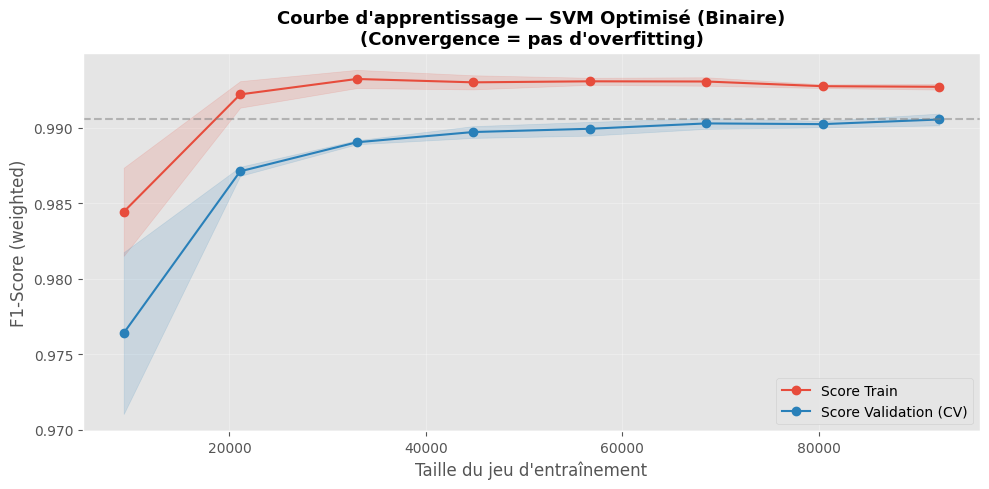

✅ Si les deux courbes convergent → pas d'overfitting


In [132]:
# =====================================================================
# 8.1.3 Diagnostic Overfitting — Binaire
#        Gap train/val + Courbe d'apprentissage
# =====================================================================
import pandas as pd

# --- 1. Gap Train / Validation (meilleur estimateur) ---
cv_results_b = pd.DataFrame(grid_svm_b.cv_results_)
best_idx_b = grid_svm_b.best_index_

train_score_best = cv_results_b.loc[best_idx_b, 'mean_train_score']
val_score_best   = cv_results_b.loc[best_idx_b, 'mean_test_score']
gap_b = train_score_best - val_score_best

print('=' * 60)
print('DIAGNOSTIC OVERFITTING — Binaire')
print('=' * 60)
print(f'  F1 Train (CV moyen) : {train_score_best:.4f}')
print(f'  F1 Val   (CV moyen) : {val_score_best:.4f}')
print(f'  Gap Train-Val       : {gap_b:.4f}')
if gap_b < 0.02:
    print("  ✅ Pas d'overfitting (gap < 2%)")
elif gap_b < 0.05:
    print("  ⚠️  Léger overfitting (gap 2-5%) — acceptable")
else:
    print("  ❌ Overfitting significatif (gap > 5%) — ajuster C")

# --- 2. Courbe d'apprentissage ---
print('\n🔄 Calcul de la courbe d\'apprentissage...')
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    svm_opt_b, X_train_b_opt, y1_train_opt,
    cv=skf, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores_lc.mean(axis=1)
train_std  = train_scores_lc.std(axis=1)
val_mean   = val_scores_lc.mean(axis=1)
val_std    = val_scores_lc.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='#e74c3c', label='Score Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')
plt.plot(train_sizes, val_mean, 'o-', color='#2980b9', label='Score Validation (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2980b9')
plt.axhline(y=val_mean[-1], color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('F1-Score (weighted)')
plt.title('Courbe d\'apprentissage — SVM Optimisé (Binaire)\n(Convergence = pas d\'overfitting)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Si les deux courbes convergent → pas d'overfitting")

### 8.1.4 Classification Multi-classes — GridSearchCV avec Cross-Validation

SVM OPTIMISÉ — MULTI-CLASSES (GridSearchCV + StratifiedKFold)
Fitting 3 folds for each of 4 candidates, totalling 12 fits
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=linear, gamma=scale...
   ⏳ Fitting SVM with C=1, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...


/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


      ✅ Done in 89.7s
   ⏳ Fitting SVM with C=10, kernel=rbf, gamma=scale...


/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


      ✅ Done in 205.0s


...

      ✅ Done in 62.9s


/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


      ✅ Done in 60.4s
   ⏳ Fitting SVM with C=10, kernel=linear, gamma=scale...


/Users/ayoubkallel/PFA2/-Intelligent-Anomaly-Monitoring-in-5G-networks/venv/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=3000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


      ✅ Done in 61.2s
   ⏳ Fitting SVM with C=10, kernel=linear, gamma=scale...
      ✅ Done in 37.5s

✅ GridSearch terminé en 713.9s
   Meilleurs paramètres : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
   Meilleur F1 (CV val) : 0.8971

RÉSULTATS — SVM Optimisé Multi-classes
  Accuracy            : 0.7759
  Precision (weighted): 0.9770
  Recall (weighted)   : 0.7759
  F1-Score (weighted) : 0.8592

📊 Classification Report :
                    precision    recall  f1-score   support

    backhaul_issue       0.18      0.89      0.30       126
  handover_failure       0.05      0.86      0.09       116
  hardware_failure       0.17      0.57      0.27       100
      interference       0.06      0.85      0.11       111
network_congestion       0.25      0.85      0.39        95
            normal       1.00      0.78      0.87     41226
          overload       0.07      0.44      0.12       104
   security_attack       0.05      0.48      0.09       102
signal_degradation       0.

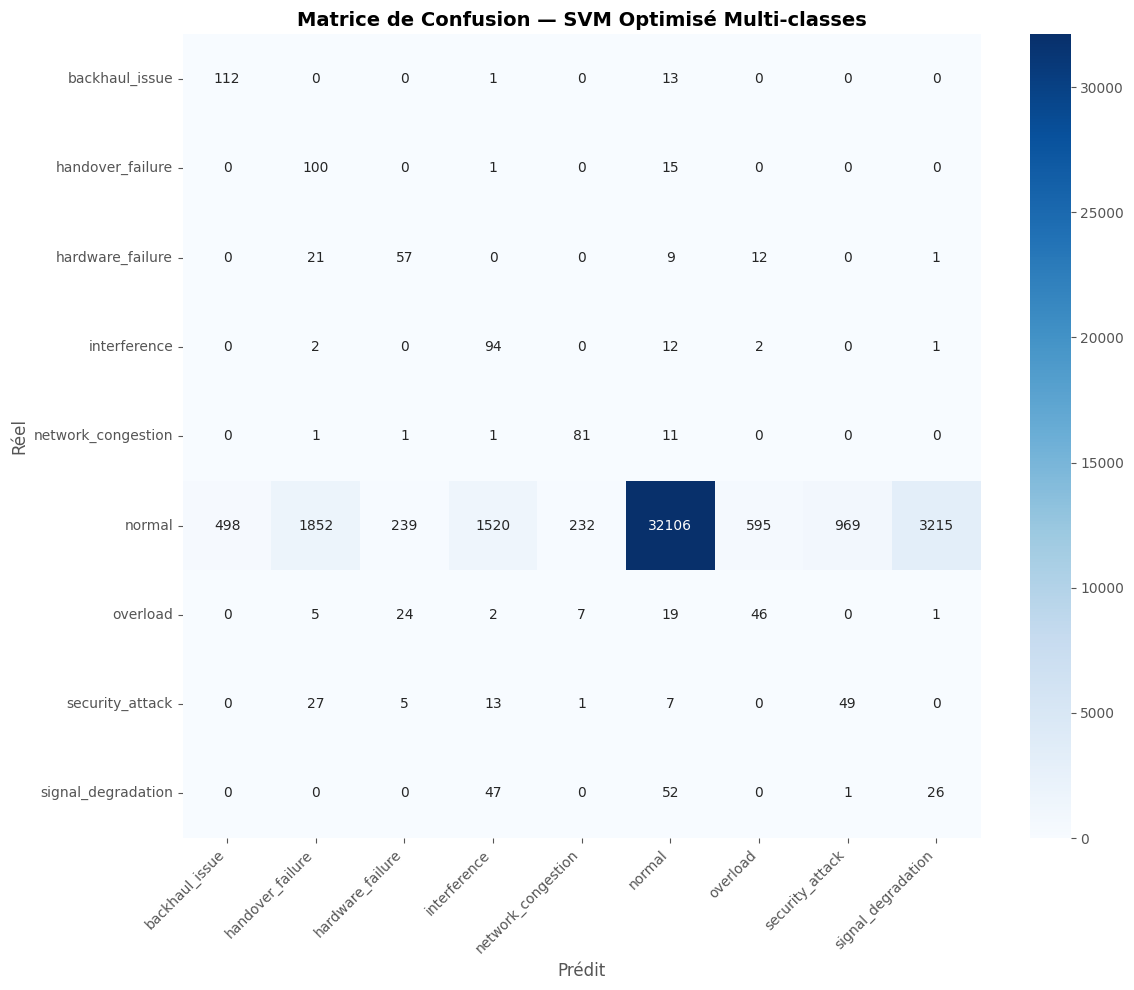

In [133]:
# =====================================================================
# 8.1.4 SVM Optimisé — Classification Multi-classes
# =====================================================================
print('=' * 70)
print('SVM OPTIMISÉ — MULTI-CLASSES (GridSearchCV + StratifiedKFold)')
print('=' * 70)

# OPTIMIZED: Using ProgressSVC wrapper with larger cache
grid_svm_m = GridSearchCV(
    ProgressSVC(
        probability=False,
        random_state=42,
        class_weight='balanced',
        decision_function_shape='ovr',
        max_iter=3000,
        cache_size=500
    ),
    param_grid_svm,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

start = time.time()
# Already using sampled multiclass data from cell 32
grid_svm_m.fit(X_train_m_opt, y2_train_opt)
elapsed = time.time() - start

print(f'\n✅ GridSearch terminé en {elapsed:.1f}s')
print(f'   Meilleurs paramètres : {grid_svm_m.best_params_}')
print(f'   Meilleur F1 (CV val) : {grid_svm_m.best_score_:.4f}')

svm_opt_m = grid_svm_m.best_estimator_
y2_pred_opt = svm_opt_m.predict(X_test_m_scaled)

acc_opt_m  = accuracy_score(y2_test, y2_pred_opt)
prec_opt_m = precision_score(y2_test, y2_pred_opt, average='weighted', zero_division=0)
rec_opt_m  = recall_score(y2_test, y2_pred_opt, average='weighted', zero_division=0)
f1_opt_m   = f1_score(y2_test, y2_pred_opt, average='weighted', zero_division=0)

print(f'\n{"="*70}')
print('RÉSULTATS — SVM Optimisé Multi-classes')
print('=' * 70)
print(f'  Accuracy            : {acc_opt_m:.4f}')
print(f'  Precision (weighted): {prec_opt_m:.4f}')
print(f'  Recall (weighted)   : {rec_opt_m:.4f}')
print(f'  F1-Score (weighted) : {f1_opt_m:.4f}')
print(f'\n📊 Classification Report :')
print(classification_report(y2_test, y2_pred_opt, target_names=le_anomaly.classes_, zero_division=0))

# --- Matrice de confusion ---
cm_opt_m = confusion_matrix(y2_test, y2_pred_opt)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_opt_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — SVM Optimisé Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

DIAGNOSTIC OVERFITTING — Multi-classes
  F1 Train (CV moyen) : 0.8980
  F1 Val   (CV moyen) : 0.8971
  Gap Train-Val       : 0.0009
  ✅ Pas d'overfitting (gap < 2%)


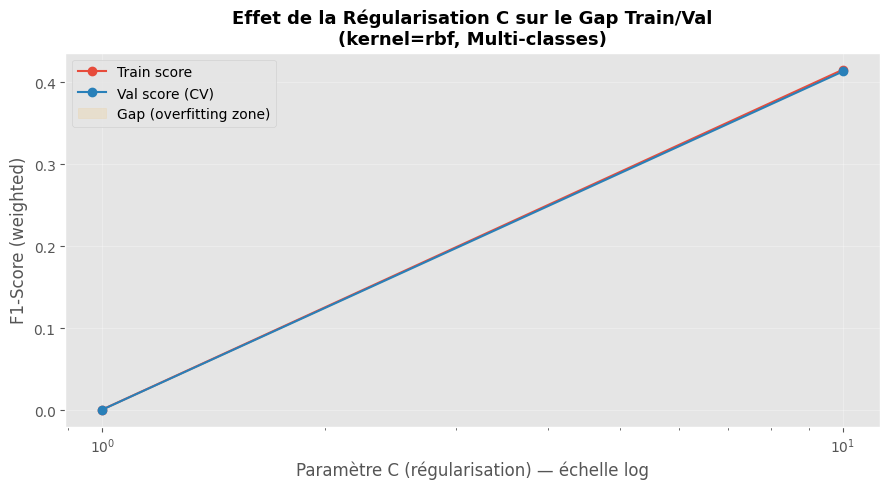

💡 Interprétation : C élevé → risque overfitting (gap large)
                    C faible → forte régularisation → meilleure généralisation


In [134]:
# =====================================================================
# 8.1.5 Diagnostic Overfitting — Multi-classes
# =====================================================================
cv_results_m = pd.DataFrame(grid_svm_m.cv_results_)
best_idx_m = grid_svm_m.best_index_

train_score_m = cv_results_m.loc[best_idx_m, 'mean_train_score']
val_score_m   = cv_results_m.loc[best_idx_m, 'mean_test_score']
gap_m = train_score_m - val_score_m

print('=' * 60)
print('DIAGNOSTIC OVERFITTING — Multi-classes')
print('=' * 60)
print(f'  F1 Train (CV moyen) : {train_score_m:.4f}')
print(f'  F1 Val   (CV moyen) : {val_score_m:.4f}')
print(f'  Gap Train-Val       : {gap_m:.4f}')
if gap_m < 0.02:
    print("  ✅ Pas d'overfitting (gap < 2%)")
elif gap_m < 0.05:
    print("  ⚠️  Léger overfitting (gap 2-5%) — acceptable")
else:
    print("  ❌ Overfitting significatif (gap > 5%) — réduire C")

# --- Visualisation : C vs Score (train et val) pour rbf ---
df_rbf = cv_results_m[cv_results_m['param_kernel'] == 'rbf'].copy()
df_rbf['param_C'] = df_rbf['param_C'].astype(float)
df_rbf_g = df_rbf.groupby('param_C')[['mean_train_score', 'mean_test_score']].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.semilogx(df_rbf_g['param_C'], df_rbf_g['mean_train_score'], 'o-', color='#e74c3c', label='Train score')
plt.semilogx(df_rbf_g['param_C'], df_rbf_g['mean_test_score'],  'o-', color='#2980b9', label='Val score (CV)')
plt.fill_between(df_rbf_g['param_C'],
                 df_rbf_g['mean_train_score'],
                 df_rbf_g['mean_test_score'],
                 alpha=0.1, color='orange', label='Gap (overfitting zone)')
plt.xlabel('Paramètre C (régularisation) — échelle log')
plt.ylabel('F1-Score (weighted)')
plt.title('Effet de la Régularisation C sur le Gap Train/Val\n(kernel=rbf, Multi-classes)', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('💡 Interprétation : C élevé → risque overfitting (gap large)')
print('                    C faible → forte régularisation → meilleure généralisation')

## 8.3 Analyse Comparative — Baseline vs Optimisé 

COMPARAISON COMPLÈTE — Classification Binaire
        Modèle  Accuracy  F1-Score  ROC-AUC  Train-Val Gap
  SVM Baseline  0.995155  0.872500 0.914301            NaN
SVM GridSearch  0.990975  0.798729 0.937706         0.0022

COMPARAISON COMPLÈTE — Classification Multi-classes
        Modèle  Accuracy  F1-Score  Precision   Recall  Train-Val Gap
  SVM Baseline  0.083432  0.126071   0.976786 0.083432            NaN
SVM GridSearch  0.775923  0.859242   0.977043 0.775923         0.0009


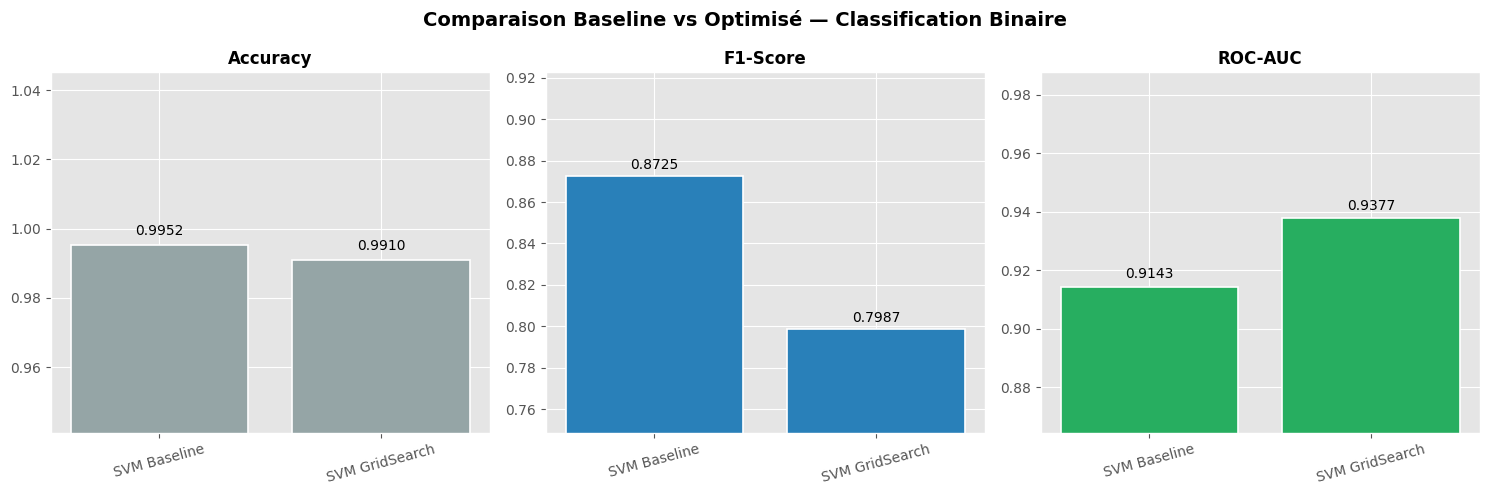

In [137]:
# =====================================================================
# 8.3 Tableau comparatif & visualisation
# =====================================================================

# --- Classification Binaire ---
results_binaire = pd.DataFrame({
    'Modèle': ['SVM Baseline', 'SVM GridSearch'],
    'Accuracy': [
        acc_baseline,
        acc_opt_b
    ],
    'F1-Score': [
        f1_baseline,
        f1_opt_b
    ],
    'ROC-AUC': [
        auc_baseline,
        auc_opt_b
    ],
    'Train-Val Gap': [
        None,
        round(gap_b, 4)
    ]
})

print('=' * 70)
print('COMPARAISON COMPLÈTE — Classification Binaire')
print('=' * 70)
print(results_binaire.to_string(index=False))

# --- Classification Multi-classes ---
results_multi = pd.DataFrame({
    'Modèle': ['SVM Baseline', 'SVM GridSearch'],
    'Accuracy':  [acc_baseline_m,  acc_opt_m],
    'F1-Score':  [f1_baseline_m,   f1_opt_m],
    'Precision': [prec_baseline_m, prec_opt_m],
    'Recall':    [rec_baseline_m,  rec_opt_m],
    'Train-Val Gap': [None, round(gap_m, 4)]
})

print(f'\n{"="*70}')
print('COMPARAISON COMPLÈTE — Classification Multi-classes')
print('=' * 70)
print(results_multi.to_string(index=False))

# --- Visualisation barplot comparatif (Binaire) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors  = ['#95a5a6', '#2980b9', '#27ae60']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_binaire[metric].values
    bars = ax.bar(results_binaire['Modèle'], vals, color=color, edgecolor='white', linewidth=1.2)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.05, max(vals) + 0.05))
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

fig.suptitle('Comparaison Baseline vs Optimisé — Classification Binaire',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


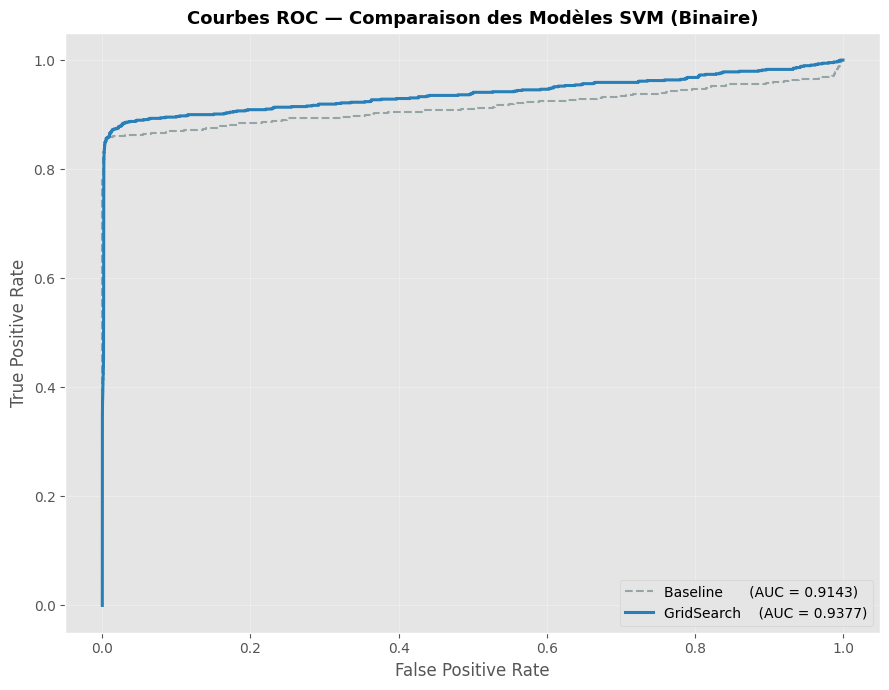

In [141]:
# =====================================================================
# 8.4 Courbes ROC — Comparaison Baseline / GridSearch
# =====================================================================

fpr_opt, tpr_opt, _ = roc_curve(y1_test, y1_proba_opt)

plt.figure(figsize=(9, 7))
plt.plot(fpr_bl,  tpr_bl,  '--', color='#95a5a6', linewidth=1.5,
         label=f'Baseline      (AUC = {auc_baseline:.4f})')
plt.plot(fpr_opt, tpr_opt, '-',  color='#2980b9', linewidth=2.2,
         label=f'GridSearch    (AUC = {auc_opt_b:.4f})')


plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Courbes ROC — Comparaison des Modèles SVM (Binaire)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8.5 Résumé — Techniques Anti-Overfitting Appliquées

| Technique | Rôle | Paramètre clé |
|---|---|---|
| **Stratified K-Fold (k=5)** | Évaluation robuste, représentation équilibrée des classes | `n_splits=5` |
| **class_weight='balanced'** | Pénalise davantage les erreurs sur classes minoritaires | automatique |
| **Régularisation C** | Contrôle le compromis biais/variance — C faible = plus de régularisation | `C ∈ [0.01, 100]` |
| **Courbe d'apprentissage** | Visualise la convergence train/val → détecte overfitting et underfitting | `learning_curve` |
| **Nested Cross-Validation** | Estimation non-biaisée de la performance généralisable | outer 3-fold |
| **Gap Train-Val** | Mesure directe de l'overfitting | `< 0.02` idéal |

### Recommandations
- Si **gap > 5%** → réduire `C`, utiliser `kernel='linear'`, ou appliquer **PCA** pour réduire la dimensionnalité.
- Si **performance faible** (underfitting) → augmenter `C`, essayer des features supplémentaires.
- Pour les **données très déséquilibrées** → combiner `class_weight='balanced'` avec **SMOTE** (oversampling).

In [144]:
# Tableau comparatif SVM (Baseline vs GridSearch vs RandomSearch)
import pandas as pd

# Parametres effectivement utilises
baseline_params_b = svm_baseline_b.get_params()
grid_best_params_b = grid_svm_b.best_params_

# Resultats
comparatif_svm = pd.DataFrame([
    {
        'Modele': 'SVM Baseline',
        'Recherche': 'Aucune',
        'Kernel': baseline_params_b.get('kernel'),
        'C': baseline_params_b.get('C'),
        'Gamma': baseline_params_b.get('gamma'),
        'Class_weight': baseline_params_b.get('class_weight'),
        'CV_F1_best': None,
        'Accuracy_test': acc_baseline,
        'Precision_test': prec_baseline,
        'Recall_test': rec_baseline,
        'F1_test': f1_baseline,
        'ROC_AUC_test': auc_baseline
    },
    {
        'Modele': 'SVM GridSearch',
        'Recherche': 'GridSearchCV',
        'Kernel': grid_best_params_b.get('kernel'),
        'C': grid_best_params_b.get('C'),
        'Gamma': grid_best_params_b.get('gamma'),
        'Class_weight': 'balanced',
        'CV_F1_best': grid_svm_b.best_score_,
        'Accuracy_test': acc_opt_b,
        'Precision_test': prec_opt_b,
        'Recall_test': rec_opt_b,
        'F1_test': f1_opt_b,
        'ROC_AUC_test': auc_opt_b
    }
])

# Arrondir pour affichage
for col in ['C', 'Gamma', 'CV_F1_best', 'Accuracy_test', 'Precision_test', 'Recall_test', 'F1_test', 'ROC_AUC_test']:
    comparatif_svm[col] = pd.to_numeric(comparatif_svm[col], errors='coerce').round(4)

print('=' * 120)
print('TABLEAU COMPARATIF - SVM Baseline vs GridSearch (Classification Binaire)')
print('=' * 120)
print(comparatif_svm.to_string(index=False))

# Version DataFrame affichable
comparatif_svm

TABLEAU COMPARATIF - SVM Baseline vs GridSearch (Classification Binaire)
        Modele    Recherche Kernel    C  Gamma Class_weight  CV_F1_best  Accuracy_test  Precision_test  Recall_test  F1_test  ROC_AUC_test
  SVM Baseline       Aucune    rbf  1.0    NaN         None         NaN         0.9952          0.9694       0.7932   0.8725        0.9143
SVM GridSearch GridSearchCV    rbf 10.0    NaN     balanced      0.9905         0.9910          0.7480       0.8568   0.7987        0.9377


,Modele,Recherche,Kernel,C,Gamma,Class_weight,CV_F1_best,Accuracy_test,Precision_test,Recall_test,F1_test,ROC_AUC_test
0,SVM Baseline,Aucune,rbf,1.0,NaN,None,NaN,0.9952,0.9694,0.7932,0.8725,0.9143
1,SVM GridSearch,GridSearchCV,rbf,10.0,NaN,balanced,0.9905,0.9910,0.7480,0.8568,0.7987,0.9377


In [146]:
# Hyperparametres utilises (details complets): k, n_iter, scoring, espaces de recherche, meilleurs params
import pandas as pd

def _format_space(v):
    if hasattr(v, 'dist') and hasattr(v, 'args'):
        return f"{v.dist.name}(args={v.args})"
    if isinstance(v, (list, tuple)):
        return ', '.join(map(str, v))
    return str(v)

# 1) Configuration des recherches (inclut k = nombre de folds)
hyperparams_config_df = pd.DataFrame([
    {
        'Methode': 'GridSearchCV',
        'k_folds': getattr(grid_svm_b.cv, 'n_splits', 'NA'),
        'n_iter': len(grid_svm_b.cv_results_['params']),
        'scoring': grid_svm_b.scoring,
        'class_weight': grid_svm_b.estimator.get_params().get('class_weight'),
        'probability': grid_svm_b.estimator.get_params().get('probability'),
        'random_state': grid_svm_b.estimator.get_params().get('random_state')
    }
])

# 2) Espaces de recherche exacts
space_grid_df = pd.DataFrame([
    {'Methode': 'GridSearchCV', 'Hyperparametre': k, 'Valeurs_utilisees': _format_space(v)}
    for k, v in param_grid_svm.items()
])

spaces_df = pd.concat([space_grid_df, space_rand_df], ignore_index=True)

# 3) Meilleurs hyperparametres trouves
best_hyperparams_df = pd.DataFrame([
    {
        'Methode': 'GridSearchCV',
        'best_kernel': grid_svm_b.best_params_.get('kernel'),
        'best_C': grid_svm_b.best_params_.get('C'),
        'best_gamma': grid_svm_b.best_params_.get('gamma'),
        'best_CV_F1': grid_svm_b.best_score_
    }
])

best_hyperparams_df[['best_C', 'best_gamma', 'best_CV_F1']] = best_hyperparams_df[['best_C', 'best_gamma', 'best_CV_F1']].apply(
    lambda s: pd.to_numeric(s, errors='coerce').round(4) if s.name in ['best_C', 'best_gamma', 'best_CV_F1'] else s
)

print('=' * 120)
print('HYPERPARAMETRES DE CONFIGURATION (k, n_iter, scoring, etc.)')
print('=' * 120)
print(hyperparams_config_df.to_string(index=False))

print('\n' + '=' * 120)
print('ESPACES DE RECHERCHE UTILISES')
print('=' * 120)
print(spaces_df.to_string(index=False))

print('\n' + '=' * 120)
print('MEILLEURS HYPERPARAMETRES TROUVES')
print('=' * 120)
print(best_hyperparams_df.to_string(index=False))

hyperparams_config_df, spaces_df, best_hyperparams_df

HYPERPARAMETRES DE CONFIGURATION (k, n_iter, scoring, etc.)
     Methode  k_folds  n_iter     scoring class_weight  probability  random_state
GridSearchCV        3       4 f1_weighted     balanced        False            42

ESPACES DE RECHERCHE UTILISES
           Methode Hyperparametre               Valeurs_utilisees
      GridSearchCV              C                           1, 10
      GridSearchCV         kernel                     rbf, linear
      GridSearchCV          gamma                           scale
RandomizedSearchCV              C loguniform(args=(0.001, 100.0))
RandomizedSearchCV          gamma  loguniform(args=(0.0001, 1.0))
RandomizedSearchCV         kernel                     rbf, linear

MEILLEURS HYPERPARAMETRES TROUVES
     Methode best_kernel  best_C  best_gamma  best_CV_F1
GridSearchCV         rbf      10         NaN      0.9905


(        Methode  k_folds  n_iter      scoring class_weight  probability  \
 0  GridSearchCV        3       4  f1_weighted     balanced        False   
 
    random_state  
 0            42  ,
               Methode Hyperparametre                Valeurs_utilisees
 0        GridSearchCV              C                            1, 10
 1        GridSearchCV         kernel                      rbf, linear
 2        GridSearchCV          gamma                            scale
 3  RandomizedSearchCV              C  loguniform(args=(0.001, 100.0))
 4  RandomizedSearchCV          gamma   loguniform(args=(0.0001, 1.0))
 5  RandomizedSearchCV         kernel                      rbf, linear,
         Methode best_kernel  best_C  best_gamma  best_CV_F1
 0  GridSearchCV         rbf      10         NaN      0.9905)